In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [2]:
df.shape

(80000, 31)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df.replace("", np.nan, inplace=True)

In [5]:
#checking missing values
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

,0
student_id,0
age,0
gender,0
major,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0


In [6]:
# Remove unnecessary columns
df = df.drop(columns=['student_id','index','major','previous_gpa','time_management_score','learning_style','exam_anxiety_score','motivation_level','parental_support_level','family_income_range','study_environment','semester','screen_time','social_activity','dropout_risk','stress_level','access_to_tutoring', 'attendance_percentage','exercise_frequency','diet_quality','parental_education_level','internet_quality','netflix_hours','mental_health_rating','extracurricular_participation','exam_score'], errors='ignore')
df.head()

,age,gender,study_hours_per_day,social_media_hours,part_time_job,sleep_hours
0,26,Male,7.645367,3.0,Yes,6.2
1,28,Male,5.700000,0.5,No,7.2
2,17,Male,2.400000,4.2,No,9.2
3,27,Other,3.400000,4.6,Yes,4.2
4,25,Female,4.700000,0.8,Yes,6.5


In [7]:
df.describe()

,age,study_hours_per_day,social_media_hours,sleep_hours
count,80000.000000,80000.000000,80000.000000,80000.000000
mean,22.004288,4.174388,2.501366,7.017417
std,3.745570,2.004135,1.445441,1.467377
min,16.000000,0.000000,0.000000,4.000000
25%,19.000000,2.800000,1.200000,6.000000
50%,22.000000,4.125624,2.500000,7.000000
75%,25.000000,5.500000,3.800000,8.000000
max,28.000000,12.000000,5.000000,12.000000


In [8]:
#removing duplicates
df = df.drop_duplicates()


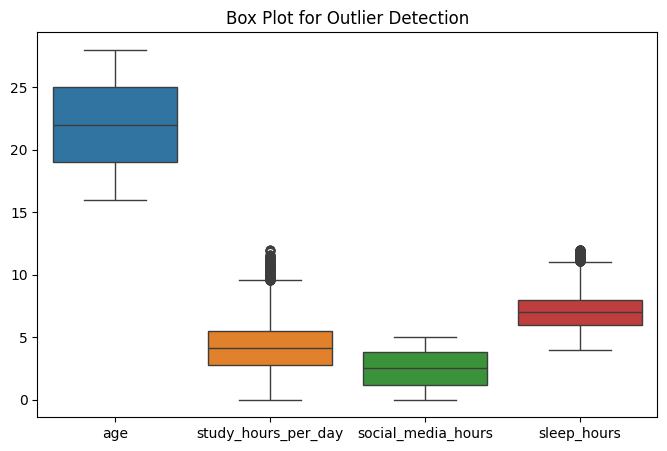

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[['age','study_hours_per_day','social_media_hours','sleep_hours']])

plt.title("Box Plot for Outlier Detection")
plt.show()

In [10]:
df.shape

(79813, 6)

In [11]:
#define total social hours per day
df['total_social_hours'] =  df['social_media_hours']

In [12]:
#define focus ratio
df['focus_ratio'] = df['study_hours_per_day'] / (
    df['study_hours_per_day'] + df['total_social_hours'] + 1
)

In [13]:
#define task completed
threshold = 0.5

df['task_completed'] = (
    df['focus_ratio'] +
    np.random.normal(0, 0.1, len(df))  #noise
    > threshold
).astype(int)

In [14]:
df['task_completed'].value_counts()


,count
task_completed,
1,46383
0,33430


In [15]:
features = [
    'age',
    'gender',
    'part_time_job',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

X = df[features].copy()
y = df['task_completed'].copy()

In [16]:
#    - One-hot encode categorical columns
X = pd.get_dummies(X, columns=['gender', 'part_time_job'], drop_first=True)

In [17]:
#    - Scale numeric columns
num_cols = ['age', 'study_hours_per_day', 'sleep_hours', 'total_social_hours']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [18]:
#apply smote
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

In [19]:
#split the data set to train and test
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

In [20]:
print("y (original):")
print(y.value_counts())

print("\ny_bal (after SMOTE on full dataset):")
print(y_bal.value_counts())

print("\ny_train_bal (after split):")
print(y_train_bal.value_counts())

print("\ny_test_bal (after split):")
print(y_test_bal.value_counts())

y (original):
task_completed
1    46383
0    33430
Name: count, dtype: int64

y_bal (after SMOTE on full dataset):
task_completed
1    46383
0    46383
Name: count, dtype: int64

y_train_bal (after split):
task_completed
0    37106
1    37106
Name: count, dtype: int64

y_test_bal (after split):
task_completed
0    9277
1    9277
Name: count, dtype: int64


In [21]:
#decision tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_bal)

print("Accuracy:", round(accuracy_score(y_test_bal, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred))


Accuracy: 0.835

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      9277
           1       0.82      0.85      0.84      9277

    accuracy                           0.83     18554
   macro avg       0.84      0.83      0.83     18554
weighted avg       0.84      0.83      0.83     18554



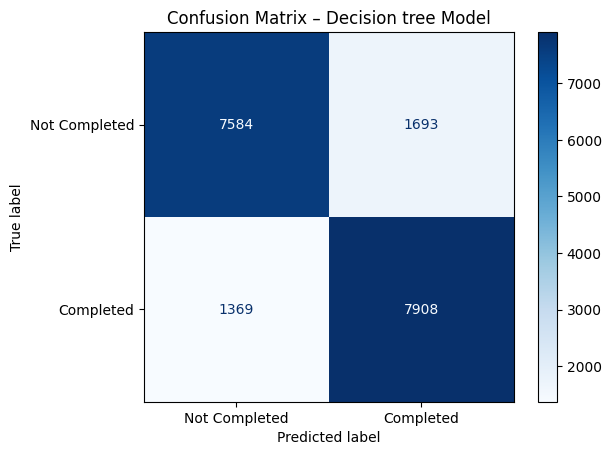

In [23]:
#evaluating the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Completed', 'Completed'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Decision tree Model")
plt.show()

In [24]:
from sklearn.metrics import accuracy_score

dt_train_pred = model.predict(X_train_bal)
dt_test_pred = model.predict(X_test_bal)

print("Decision Tree Train Accuracy:",
      round(accuracy_score(y_train_bal, dt_train_pred), 3))

print("Decision Tree Test Accuracy:",
      round(accuracy_score(y_test_bal, dt_test_pred), 3))

Decision Tree Train Accuracy: 0.835
Decision Tree Test Accuracy: 0.835


In [25]:
#random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [26]:
y_pred = rf_model.predict(X_test_bal)

In [27]:

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test_bal, y_pred))
print(classification_report(y_test_bal, y_pred))

Accuracy: 0.8449929934245984
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      9277
           1       0.85      0.84      0.84      9277

    accuracy                           0.84     18554
   macro avg       0.85      0.84      0.84     18554
weighted avg       0.85      0.84      0.84     18554



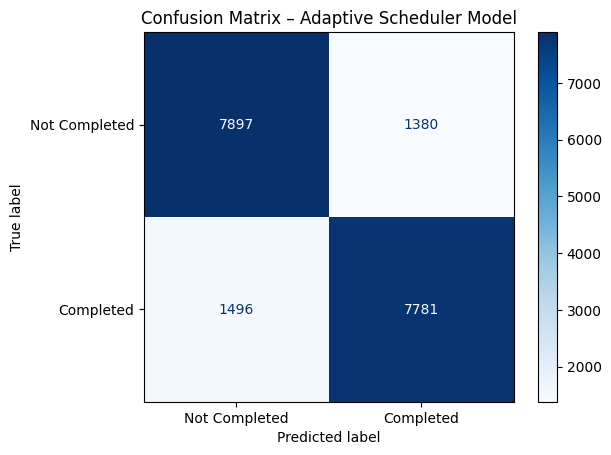

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Adaptive Scheduler Model")
plt.show()

In [29]:
rf_train_pred = rf_model.predict(X_train_bal)
rf_test_pred = rf_model.predict(X_test_bal)

print("Random Forest Train Accuracy:",
      round(accuracy_score(y_train_bal, rf_train_pred), 3))

print("Random Forest Test Accuracy:",
      round(accuracy_score(y_test_bal, rf_test_pred), 3))

Random Forest Train Accuracy: 0.852
Random Forest Test Accuracy: 0.845


In [30]:
#logistic regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # helps with class imbalance
    random_state=42
)

log_model.fit(X_train_bal, y_train_bal)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [31]:
y_pred_lr = log_model.predict(X_test_bal)

In [32]:
#evaluation
from sklearn.metrics import classification_report

accuracy_lr = accuracy_score(y_test_bal, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

print("Classification Report (Logistic Regression):")
print(classification_report(y_test_bal, y_pred_lr))

Logistic Regression Accuracy: 0.8384714886277892
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      9277
           1       0.85      0.83      0.84      9277

    accuracy                           0.84     18554
   macro avg       0.84      0.84      0.84     18554
weighted avg       0.84      0.84      0.84     18554



In [33]:
lr_train_pred = log_model.predict(X_train_bal)
lr_test_pred = log_model.predict(X_test_bal)

print("Logistic Regression Train Accuracy:",
      round(accuracy_score(y_train_bal, lr_train_pred), 3))

print("Logistic Regression Test Accuracy:",
      round(accuracy_score(y_test_bal, lr_test_pred), 3))

Logistic Regression Train Accuracy: 0.836
Logistic Regression Test Accuracy: 0.838


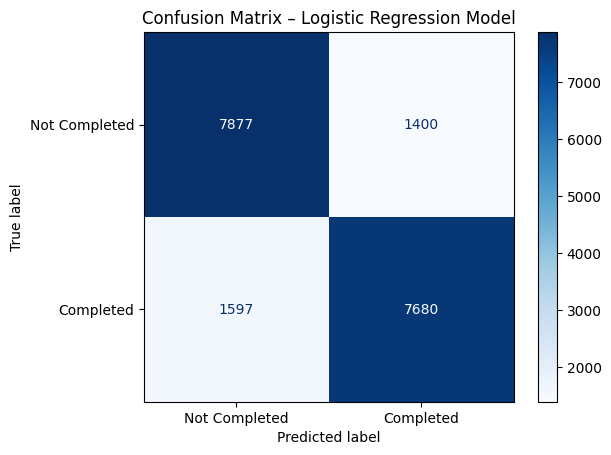

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test_bal, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression Model")
plt.show()

In [35]:
#tuning the dt model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define base model
dt = DecisionTreeClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # better than accuracy for imbalance
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 50}


In [36]:
#train the model
best_dt = grid_search.best_estimator_

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_dt.predict(X_test_bal)

print("Tuned Decision Tree Accuracy:", round(accuracy_score(y_test_bal, y_pred), 3))

print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred))



Tuned Decision Tree Accuracy: 0.839

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      9277
           1       0.85      0.83      0.84      9277

    accuracy                           0.84     18554
   macro avg       0.84      0.84      0.84     18554
weighted avg       0.84      0.84      0.84     18554



In [38]:
best_dt_train_pred = best_dt.predict(X_train_bal)
best_dt_test_pred = best_dt.predict(X_test_bal)

print("Tuned Decision Tree Train Accuracy:",
      round(accuracy_score(y_train_bal, best_dt_train_pred), 3))

print("Tuned Decision Tree Test Accuracy:",
      round(accuracy_score(y_test_bal, best_dt_test_pred), 3))

Tuned Decision Tree Train Accuracy: 0.847
Tuned Decision Tree Test Accuracy: 0.839


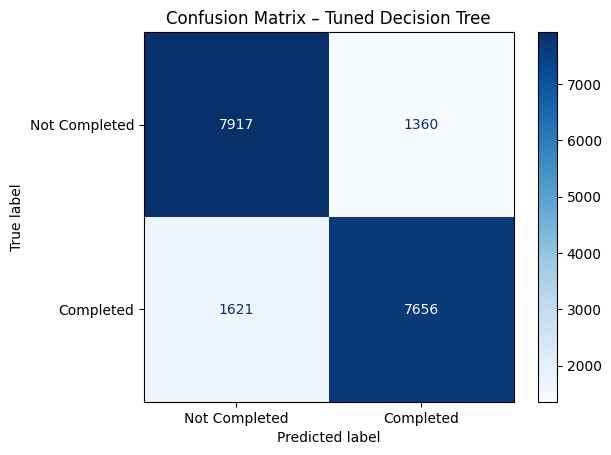

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_dt,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)

plt.title("Confusion Matrix – Tuned Decision Tree")
plt.show()

In [40]:
#tuning the lr model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base logistic regression
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

# Small + effective grid (fast)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="f1",     # best for imbalance
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = best_lr.predict(X_test_bal)

print("Tuned Logistic Regression Accuracy:", round(accuracy_score(y_test_bal, y_pred_lr), 3))
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test_bal, y_pred_lr))


Tuned Logistic Regression Accuracy: 0.838

Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      9277
           1       0.85      0.83      0.84      9277

    accuracy                           0.84     18554
   macro avg       0.84      0.84      0.84     18554
weighted avg       0.84      0.84      0.84     18554



In [42]:
best_lr_train_pred = best_lr.predict(X_train_bal)
best_lr_test_pred = best_lr.predict(X_test_bal)

print("Tuned Logistic Regression Train Accuracy:",
      round(accuracy_score(y_train_bal, best_lr_train_pred), 3))

print("Tuned Logistic Regression Test Accuracy:",
      round(accuracy_score(y_test_bal, best_lr_test_pred), 3))

Tuned Logistic Regression Train Accuracy: 0.836
Tuned Logistic Regression Test Accuracy: 0.838


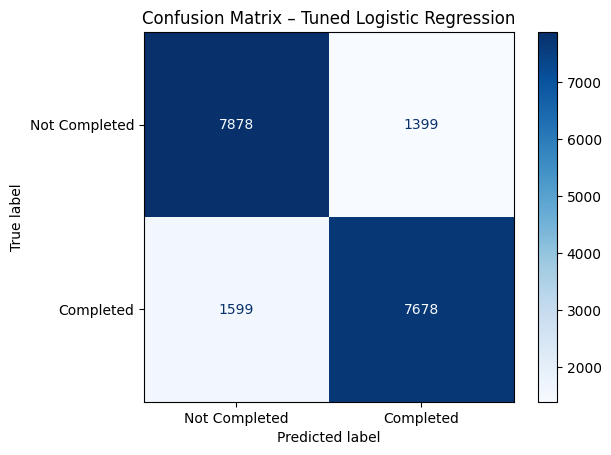

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)

plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Base model (fast settings for tuning)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Small grid = low running time
param_grid = {
    "n_estimators": [100, 150],     # smaller range
    "max_depth": [8, 12],           # controlled depth
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt"]        # fix to reduce search
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,               # faster than 5-fold
    scoring="f1",       # better for imbalance
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 150}


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = best_rf.predict(X_test_bal)

print("Tuned Random Forest Accuracy:", round(accuracy_score(y_test_bal, y_pred_rf), 3))
print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred_rf))


Tuned Random Forest Accuracy: 0.845

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      9277
           1       0.85      0.84      0.84      9277

    accuracy                           0.85     18554
   macro avg       0.85      0.85      0.85     18554
weighted avg       0.85      0.85      0.85     18554



In [46]:
best_rf_train_pred = best_rf.predict(X_train_bal)
best_rf_test_pred = best_rf.predict(X_test_bal)

print("Tuned Random Forest Train Accuracy:",
      round(accuracy_score(y_train_bal, best_rf_train_pred), 3))

print("Tuned Random Forest Test Accuracy:",
      round(accuracy_score(y_test_bal, best_rf_test_pred), 3))

Tuned Random Forest Train Accuracy: 0.862
Tuned Random Forest Test Accuracy: 0.845


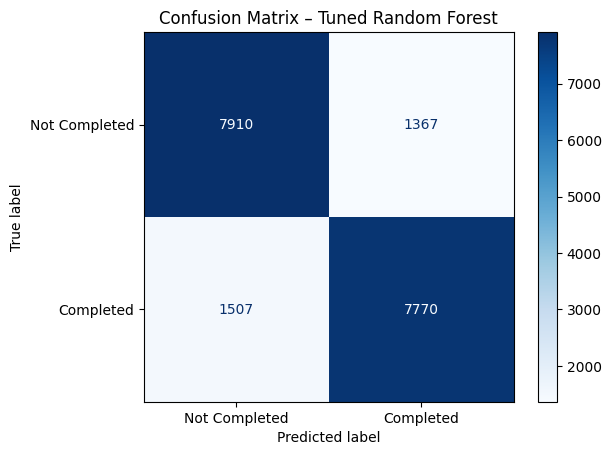

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)
plt.title("Confusion Matrix – Tuned Random Forest")
plt.show()

In [48]:

feature_importance = pd.DataFrame({
    'feature': X_train_bal.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
1,study_hours_per_day,0.580717
3,total_social_hours,0.387511
2,sleep_hours,0.014983
0,age,0.012975
6,part_time_job_Yes,0.001576
4,gender_Male,0.001128
5,gender_Other,0.001111


In [49]:
#comparison
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

models = {
    "Tuned Decision Tree": best_dt,
    "Tuned Random Forest": best_rf,
    "Tuned Logistic Regression": best_lr
}

results = []

for name, model in models.items():
    # Predict class labels
    y_pred = model.predict(X_test_bal)

    # Basic metrics
    acc = accuracy_score(y_test_bal, y_pred)
    prec = precision_score(y_test_bal, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test_bal, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test_bal, y_pred, pos_label=1, zero_division=0)

    # ROC-AUC (only if model supports predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_bal)[:, 1]
        auc = roc_auc_score(y_test_bal, y_prob)
    else:
        auc = None

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision (Class 1)": round(prec, 3),
        "Recall (Class 1)": round(rec, 3),
        "F1-score (Class 1)": round(f1, 3),
        "ROC-AUC": round(auc, 3) if auc is not None else "N/A"
    })

# Create comparison table
results_df = pd.DataFrame(results).sort_values(by="F1-score (Class 1)", ascending=False)
print(results_df)

                       Model  Accuracy  Precision (Class 1)  Recall (Class 1)  \
1        Tuned Random Forest     0.845                0.850             0.838   
0        Tuned Decision Tree     0.839                0.849             0.825   
2  Tuned Logistic Regression     0.838                0.846             0.828   

   F1-score (Class 1)  ROC-AUC  
1               0.844    0.928  
0               0.837    0.923  
2               0.837    0.919  


In [50]:
#check the overfitting for tuned rf model
train_pred = best_rf.predict(X_train_bal)

print("Train Accuracy:",
      round(accuracy_score(y_train_bal, train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test_bal, y_pred_rf), 3))

Train Accuracy: 0.862
Test Accuracy: 0.845


In [51]:
#ROC_AUC score
from sklearn.metrics import roc_auc_score

y_prob_rf = best_rf.predict_proba(X_test_bal)[:, 1]
roc_auc = roc_auc_score(y_test_bal, y_prob_rf)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.928


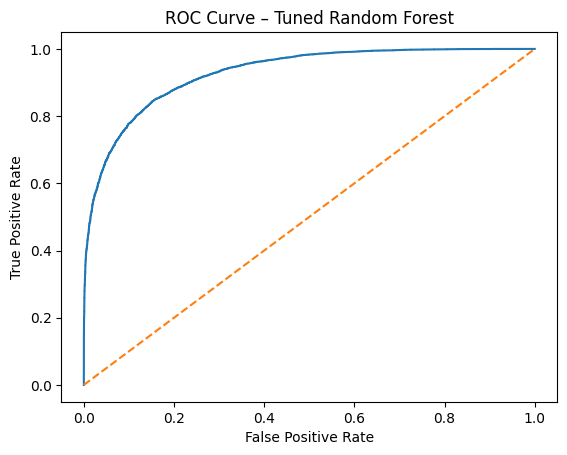

In [52]:
#ROC curve plot
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_bal, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Random Forest")
plt.show()

In [53]:
#Cross-Validation Score (Model Stability)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train_bal, y_train_bal, cv=3, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", round(cv_scores.mean(), 3))

Cross-validation F1 scores: [0.83718847 0.84229651 0.84185725]
Mean CV F1 score: 0.84


In [54]:
import joblib

joblib.dump(best_rf, "adaptive_planner_model.pkl")

['adaptive_planner_model.pkl']

In [55]:
import pandas as pd
import joblib
import random
from datetime import datetime

# -----------------------------
# 1. Load saved Random Forest model
# -----------------------------
model = joblib.load("adaptive_planner_model.pkl")

# -----------------------------
# 2. Keep the same training columns and scaler
#    (must already exist in your notebook)
# -----------------------------
feature_columns = X_train_bal.columns.tolist()

# Numeric columns used during scaling
num_cols = [
    'age',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

# -----------------------------
# 3. Feedback message library
# -----------------------------
FEEDBACK_MESSAGES = {
    "recovery": [
        "Your energy seems low today. Try a lighter task and take a short break.",
        "Sleep looks a bit low — start with a smaller task and recover your rhythm.",
        "A short reset may help. Continue with an easier task first."
    ],
    "missed_support": [
        "No worries — the missed task can be moved to the next available slot.",
        "You missed a slot, so the plan can be adjusted to keep it manageable.",
        "It’s okay to miss sometimes — the task can be rescheduled smoothly."
    ],
    "refocus": [
        "Try reducing distractions and focus on one short task first.",
        "A quick reset may help — complete one focused block now.",
        "Close distractions for a while and continue with a smaller goal."
    ],
    "streak": [
        "Great consistency! Keep the streak going.",
        "You’re building a strong study routine — well done.",
        "Nice progress so far. Keep the momentum going."
    ],
    "praise": [
        "Good job — your productivity looks strong right now.",
        "You’re on track. Keep following the current plan.",
        "Your current pattern looks productive — continue as planned."
    ],
    "encourage": [
        "You’re doing okay. Keep working steadily on the next task.",
        "Small progress matters — continue with the next step.",
        "Stay consistent and complete one task at a time."
    ]
}

SUGGESTED_ACTIONS = {
    "recovery": "Switch to a lighter task",
    "missed_support": "Reschedule task to next available slot",
    "refocus": "Start a short focus session",
    "streak": "Maintain the current study flow",
    "praise": "Continue with the current task",
    "encourage": "Proceed with the next planned task"
}

# -----------------------------
# 4. Feedback rule engine
# -----------------------------
def choose_feedback_type(p_complete, sleep_hours, total_social_hours, streak=0, missed_count_today=0):
    if sleep_hours < 6:
        return "recovery"
    if missed_count_today >= 1:
        return "missed_support"
    if p_complete < 0.5 and total_social_hours >= 4:
        return "refocus"
    if streak >= 3:
        return "streak"
    if p_complete >= 0.75:
        return "praise"
    return "encourage"

def generate_feedback(p_complete, sleep_hours, total_social_hours, streak=0, missed_count_today=0):
    feedback_type = choose_feedback_type(
        p_complete=p_complete,
        sleep_hours=sleep_hours,
        total_social_hours=total_social_hours,
        streak=streak,
        missed_count_today=missed_count_today
    )
    message = random.choice(FEEDBACK_MESSAGES[feedback_type])
    return {
        "feedback_type": feedback_type,
        "message": message,
        "suggested_action": SUGGESTED_ACTIONS[feedback_type],
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

# -----------------------------
# 5. Prepare new student input
# -----------------------------
def prepare_input(student_data):
    input_df = pd.DataFrame([student_data])

    # One-hot encode
    input_df = pd.get_dummies(input_df, columns=['gender', 'part_time_job'], drop_first=True)

    # Match training columns exactly
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # Apply same scaling used in training
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    return input_df

# -----------------------------
# 6. Find next available slot
# -----------------------------
def find_next_available_slot(schedule):
    for slot in schedule:
        if slot["status"] == "free":
            return slot["time"]
    return "Next Day"

# -----------------------------
# 7. Adaptive planner integration
# -----------------------------
def adaptive_planner(student_data, schedule, streak=0, missed_count_today=0):
    prepared_input = prepare_input(student_data)

    # Prediction
    p_complete = model.predict_proba(prepared_input)[0][1]
    prediction = model.predict(prepared_input)[0]

    # Scheduling logic
    if p_complete >= 0.7:
        planner_decision = "Keep task in current slot"
        new_slot = None
    elif p_complete >= 0.4:
        planner_decision = "Shorten task duration"
        new_slot = None
    else:
        planner_decision = "Reschedule task"
        new_slot = find_next_available_slot(schedule)

    # Feedback generation
    feedback = generate_feedback(
        p_complete=p_complete,
        sleep_hours=student_data["sleep_hours"],
        total_social_hours=student_data["total_social_hours"],
        streak=streak,
        missed_count_today=missed_count_today
    )

    return {
        "prediction": int(prediction),
        "task_completion_probability": round(p_complete, 3),
        "planner_decision": planner_decision,
        "new_slot": new_slot,
        "feedback": feedback
    }



In [56]:
# -----------------------------
# 8. Example usage
# -----------------------------
student_data = {
    "age": 18,
    "gender": "Male",
    "part_time_job": "No",
    "study_hours_per_day": 4,
    "sleep_hours": 5,
    "total_social_hours": 2
}

schedule = [
    {"time": "4:00 PM - 5:00 PM", "status": "occupied"},
    {"time": "6:00 PM - 7:00 PM", "status": "free"},
    {"time": "8:00 PM - 9:00 PM", "status": "free"}
]

result = adaptive_planner(student_data, schedule, streak=2, missed_count_today=1)

print("Prediction:", result["prediction"])
print("Task Completion Probability:", result["task_completion_probability"])
print("Planner Decision:", result["planner_decision"])
print("New Slot:", result["new_slot"])
print("Feedback Type:", result["feedback"]["feedback_type"])
print("Feedback Message:", result["feedback"]["message"])
print("Suggested Action:", result["feedback"]["suggested_action"])

Prediction: 1
Task Completion Probability: 0.742
Planner Decision: Keep task in current slot
New Slot: None
Feedback Type: recovery
Feedback Message: A short reset may help. Continue with an easier task first.
Suggested Action: Switch to a lighter task


In [57]:
import random
from datetime import datetime


# Feedback Message Library

FEEDBACK_MESSAGES = {
    "recovery": [
        "Your energy seems low today. Try a lighter task and take short breaks.",
        "Sleep looks a bit low — let’s do a small task now and recover your rhythm.",
        "Take 5 minutes to reset, then continue with an easier task."
    ],
    "missed_support": [
        "No worries — I’ll reschedule the missed task to the next available slot.",
        "You missed a slot. Let’s adjust the plan so it stays manageable.",
        "It’s okay to miss sometimes — we’ll fit the task into a better time."
    ],
    "refocus": [
        "Quick reset: close distractions and focus for 15 minutes. You’ve got this.",
        "Try one focused block first, then reward yourself with a short break.",
        "Let’s reduce distractions for a moment and finish one small task."
    ],
    "streak": [
        "Great streak! You’re building a strong routine — keep it going!",
        "Amazing consistency — you’ve earned a short reward break!",
        "Your streak is impressive. One more task will make it even better!"
    ],
    "praise": [
        "Great progress — keep the momentum going!",
        "You’re in a strong focus zone. Let’s finish strong!",
        "Nice work! Your study pattern looks solid today."
    ],
    "encourage": [
        "You’re doing okay — let’s aim to complete the next task calmly.",
        "Small steps matter. Try a 20-minute focus session now.",
        "Keep going — staying consistent is more important than being perfect."
    ]
}

In [58]:
#actions that show in UI
SUGGESTED_ACTIONS = {
    "recovery": "Switch to a lighter task / add a short break",
    "missed_support": "Reschedule missed task to next free slot",
    "refocus": "Start a 15–25 minute focus block (Pomodoro)",
    "streak": " reward with short break",
    "praise": "Continue with next planned task",
    "encourage": "Do the next task with a small goal"
}


In [59]:

#category selection
#Priority: recovery > missed_support > refocus >praise > encourage

def choose_feedback_type(p_complete: float,
                         sleep_hours: float,
                         total_social_hours: float,

                         missed_count_today: int = 0,
                         social_high_threshold: float = 4.0) -> str:
    """
    Returns one feedback category based on simple rules.
    """

    # 1) Recovery (low sleep)
    if sleep_hours is not None and sleep_hours < 6:
        return "recovery"

    # 2) Missed-task support
    if missed_count_today is not None and missed_count_today >= 1:
        return "missed_support"

    # 3) Refocus (low predicted completion + high distraction time)
    if (p_complete is not None and p_complete < 0.5) and (total_social_hours is not None and total_social_hours >= social_high_threshold):
        return "refocus"

    # 4) Praise (high completion probability)
    if p_complete is not None and p_complete >= 0.75:
        return "praise"

    # 5) Default encouragement
    return "encourage"

In [60]:
def generate_feedback(p_complete: float,
                      sleep_hours: float,
                      total_social_hours: float,
                      missed_count_today: int = 0) -> dict:
    """
    Returns feedback output object for UI integration.
    """
    fb_type = choose_feedback_type(
        p_complete=p_complete,
        sleep_hours=sleep_hours,
        total_social_hours=total_social_hours,

        missed_count_today=missed_count_today
    )

    message = random.choice(FEEDBACK_MESSAGES[fb_type])
    action = SUGGESTED_ACTIONS.get(fb_type, "")

    return {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "feedback_type": fb_type,
        "message": message,
        "suggested_action": action
    }

In [61]:
# Example: student likely distracted + high social hours
feedback = generate_feedback(
    p_complete=0.80,
    sleep_hours=7.0,
    total_social_hours=5.5,
    missed_count_today=0
)

print(feedback)

{'timestamp': '2026-03-16T16:59:06', 'feedback_type': 'praise', 'message': 'Nice work! Your study pattern looks solid today.', 'suggested_action': 'Continue with next planned task'}
